**Global Happiness Report Analysis**

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/WHR_2015.csv")
df.head(2)

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,Western Europe,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145


**Data Preparation**

In [ ]:
df.shape

(158, 9)

In [ ]:
df.columns

Index(['country', 'region', 'happiness_score', 'gdp_per_capita',
       'social_support', 'healthy_life_expectancy',
       'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       158 non-null    object 
 1   region                        158 non-null    object 
 2   happiness_score               158 non-null    float64
 3   gdp_per_capita                158 non-null    float64
 4   social_support                158 non-null    float64
 5   healthy_life_expectancy       158 non-null    float64
 6   freedom_to_make_life_choices  158 non-null    float64
 7   generosity                    158 non-null    float64
 8   perceptions_of_corruption     158 non-null    float64
dtypes: float64(7), object(2)
memory usage: 11.2+ KB


In [ ]:
df.describe()

,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,5.375734,0.846137,0.991046,0.630259,0.428615,0.237296,0.143422
std,1.145010,0.403121,0.272369,0.247078,0.150693,0.126685,0.120034
min,2.839000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.526000,0.545808,0.856823,0.439185,0.328330,0.150553,0.061675
50%,5.232500,0.910245,1.029510,0.696705,0.435515,0.216130,0.107220
75%,6.243750,1.158448,1.214405,0.811013,0.549092,0.309883,0.180255
max,7.587000,1.690420,1.402230,1.025250,0.669730,0.795880,0.551910


In [ ]:
df.isnull().sum()

,0
country,0
region,0
happiness_score,0
gdp_per_capita,0
social_support,0
healthy_life_expectancy,0
freedom_to_make_life_choices,0
generosity,0
perceptions_of_corruption,0


**Data Analysis**

In [ ]:
h = df.groupby("country")["happiness_score"].mean().nlargest(5)
h.reset_index()

,country,happiness_score
0,Switzerland,7.587
1,Iceland,7.561
2,Denmark,7.527
3,Norway,7.522
4,Canada,7.427


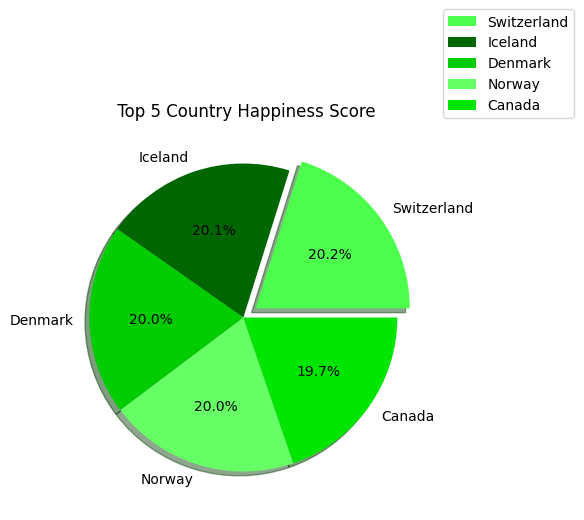

In [ ]:
plt.figure(figsize=(5,5))
color = ["#4dff4d","#006600","#00cc00","#66ff66","#00e600"]
plt.pie(h.values,labels=h.index,autopct="%1.1f%%",explode=[0.1,0,0,0,0],shadow=True,colors=color)
plt.title(" Top 5 Country Happiness Score")
plt.legend(bbox_to_anchor=(1,1))
plt.savefig("Top 5 Country Happiness Score.png", bbox_inches="tight")
plt.show()

**Top 5 Country Happiness Score**

*   Highest Happiness Score is **Switzerland** Country
*   Second Happiness Score is **lceland** Country
*   Lowest Happiness Score is **Togo** Country



In [ ]:
high_gep_happ = df.groupby("happiness_score")["gdp_per_capita"].sum().nlargest(5)
high_gep_happ.reset_index()


,happiness_score,gdp_per_capita
0,5.192,1.87636
1,6.611,1.69042
2,6.946,1.56391
3,6.295,1.55422
4,6.798,1.52186


In [ ]:
avg = df['gdp_per_capita'].mean()
avg

np.float64(0.8461372151898735)

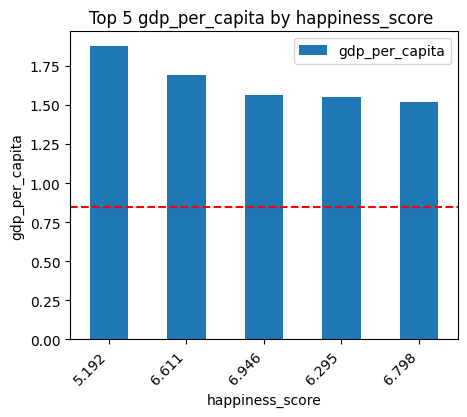

In [ ]:

plt.figure(figsize=(5,4))
high_gep_happ.plot(kind="bar")
plt.axhline(y=avg,color="red",linestyle="--")
plt.title("Top 5 gdp_per_capita by happiness_score ")
plt.ylabel("gdp_per_capita")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.savefig("Top 5 gdp_per_capita by happiness_score ", bbox_inches="tight")
plt.show()

**Top 5 gdp_per_capita by happiness_score**


*   **Highest** Gdp_Per_Capita is ~**1.87**
*   **Average** Gdp_Per_Capita is  ~**0.84**





In [ ]:
pt = df.pivot_table(index=["country","social_support"],values="happiness_score",aggfunc="sum").sort_values(by="happiness_score",ascending=False).nlargest(10,"happiness_score")
pt.reset_index()

,country,social_support,happiness_score
0,Switzerland,1.34951,7.587
1,Iceland,1.40223,7.561
2,Denmark,1.36058,7.527
3,Norway,1.33095,7.522
4,Canada,1.32261,7.427
5,Finland,1.31826,7.406
6,Netherlands,1.28017,7.378
7,Sweden,1.28907,7.364
8,New Zealand,1.31967,7.286
9,Australia,1.30923,7.284


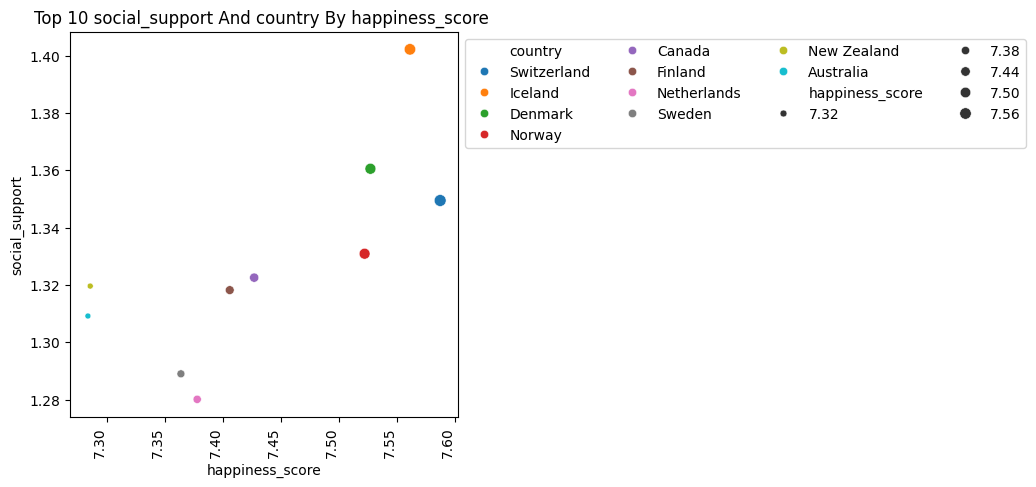

In [ ]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=pt,x='happiness_score',y="social_support",hue="country",size="happiness_score")
plt.xticks(rotation=90, ha="right")
plt.title("Top 10 social_support And country By happiness_score ")
plt.legend(ncol=4,bbox_to_anchor=(1,1))
plt.savefig("Top 10 social_support And country By happiness_score ", bbox_inches="tight")
plt.show()

**Top 10 social_support And country By happiness_score**


*   **Highest** Happiness Score By **social_support** Country **Switzerland**  



In [ ]:
he = df.groupby("country")["healthy_life_expectancy"].sum().nlargest(10)
he.reset_index()

,country,healthy_life_expectancy
0,Singapore,1.02525
1,Hong Kong S.A.R. of China,1.01328
2,Japan,0.99111
3,South Korea,0.96538
4,Spain,0.95562
5,Italy,0.95446
6,Iceland,0.94784
7,France,0.94579
8,Switzerland,0.94143
9,Australia,0.93156


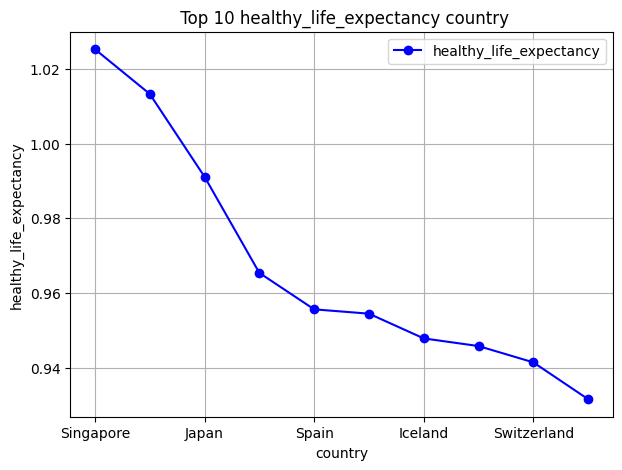

In [ ]:
plt.figure(figsize=(7,5))
he.plot(kind="line",marker="o",label="healthy_life_expectancy",color="blue")
plt.ylabel("healthy_life_expectancy")
plt.title(" Top 10 healthy_life_expectancy country")
plt.grid()
plt.legend()
plt.savefig("Top 10 healthy_life_expectancy country", bbox_inches="tight")
plt.show()

**Top 10 healthy_life_expectancy country**


*   **Highest** Top 10 healthy_life_expectancy **country** **Singapore** But Highest Happiness Score Is **Switzerland** And Top 10 Among **9** Rank On **Switzerland**




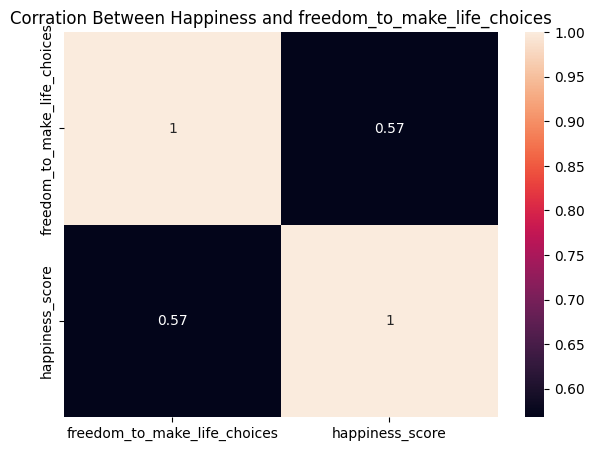

In [235]:
plt.figure(figsize=(7,5))
num = df.corr(numeric_only=True)
sns.heatmap(df[["freedom_to_make_life_choices","happiness_score"]].corr(),annot=True)
plt.title("Corration Between Happiness and freedom_to_make_life_choices")
plt.savefig("Corration Between Happiness and freedom_to_make_life_choices.png", bbox_inches="tight")
plt.show()

**Happiness and freedom_to_make_life_choices**


*   Happiness and freedom_to_make_life_choices between **moderate positive** **correlation**

